病人ID        int64
年龄          int64
性别            str
地区            str
就诊日期          str
疾病类型          str
诊断日期          str
疾病严重程度        str
治疗方案          str
治疗结果          str
药物名称          str
药物分类          str
用药剂量          str
用药时长          str
检查项目          str
检查结果      float64
参考范围          str
体重        float64
身高        float64
吸烟情况          str
饮酒情况          str
遗传病史          str
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 5440 entries, 0 to 5439
Data columns (total 22 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   病人ID    5440 non-null   int64  
 1   年龄      5440 non-null   int64  
 2   性别      5440 non-null   str    
 3   地区      5438 non-null   str    
 4   就诊日期    5439 non-null   str    
 5   疾病类型    5440 non-null   str    
 6   诊断日期    5429 non-null   str    
 7   疾病严重程度  5439 non-null   str    
 8   治疗方案    5438 non-null   str    
 9   治疗结果    5437 non-null   str    
 10  药物名称    5438 non-null   str    
 11  药物分类    

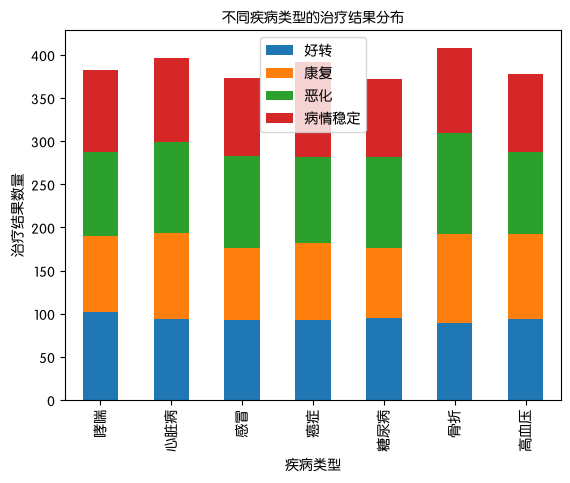

/var/folders/j3/bt37j76s7_v3gqj0604hn8zc0000gn/T/ipykernel_1887/100763497.py:85: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


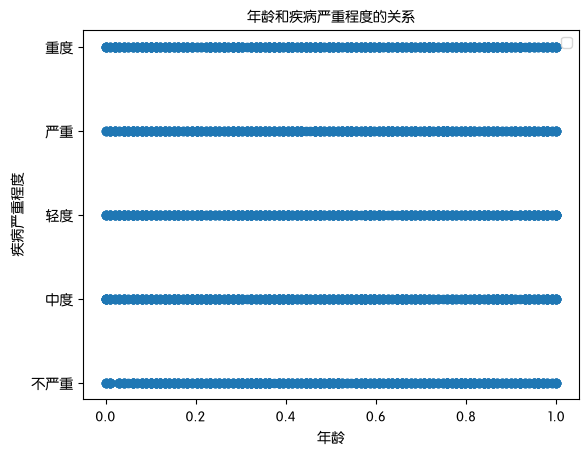

In [20]:
import pandas as pd

# 加载数据集并指定编码
file_path = 'medical_data.csv'
data = pd.read_csv(file_path, encoding='gbk')

# 查看数据类型
print(data.dtypes)
# 查看表结构
print(data.info())

# 显示每一列的空缺值数量
print(data.isnull().sum())

# 规范日期格式
data['就诊日期'] = pd.to_datetime(data['就诊日期'])
data['诊断日期'] = pd.to_datetime(data['诊断日期'])

# 重命名列
data.rename(columns={'病人ID': '患者ID'}, inplace=True)

# 查看修改后的表结构
print(data.head())

from datetime import datetime

# 增加诊断延迟和病程
data['诊断延迟'] = (data['诊断日期'] - data['就诊日期']).dt.days
data['病程'] = (datetime(2024, 9, 1) - data['诊断日期']).dt.days

# 删除不合理的数据
data = data[(data['诊断延迟'] >= 0) & (data['年龄'] > 0) & (data['年龄'] < 120)]

# 查看修改后的数据
print(data.describe())

# 删除重复值并记录删除的行数
initial_rows = data.shape[0]
data.drop_duplicates(inplace=True)
deleted_rows = initial_rows - data.shape[0]

print(f'删除的重复行数: {deleted_rows}')

from sklearn.preprocessing import MinMaxScaler

# 对需要归一化的列进行处理
scaler = MinMaxScaler()
columns_to_normalize = ['年龄', '体重', '身高']
data[columns_to_normalize] = scaler.fit_transform(data[columns_to_normalize])

# 查看归一化后的数据
print(data.head())

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


# 统计治疗结果分布
treatment_outcome_distribution = data.groupby('疾病类型')['治疗结果'].value_counts().unstack()

# 设置中文字体
# font_path = 'C:/Windows/Fonts/simhei.ttf'  # 根据你的系统调整字体路径
font_path = '/Users/agao/Library/Fonts/方正准圆简体.TTF'  # 根据你的系统调整字体路径
my_font = fm.FontProperties(fname=font_path)

# 绘制柱状图
treatment_outcome_distribution.plot(kind='bar', stacked=True)
plt.title('不同疾病类型的治疗结果分布', fontproperties=my_font)
plt.xlabel('疾病类型', fontproperties=my_font)
plt.ylabel('治疗结果数量', fontproperties=my_font)
plt.xticks(fontproperties=my_font)  # 设置x轴刻度标签的字体
plt.yticks(fontproperties=my_font)  # 设置y轴刻度标签的字体
plt.legend(prop=my_font)  # 设置图例字体
plt.show()

# # 绘制散点图
plt.scatter(data['年龄'], data['疾病严重程度'])
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.title('年龄和疾病严重程度的关系', fontproperties=my_font)
plt.xlabel('年龄', fontproperties=my_font)
plt.ylabel('疾病严重程度', fontproperties=my_font)
plt.xticks(fontproperties=my_font)  # 设置x轴刻度标签的字体
plt.yticks(fontproperties=my_font)  # 设置y轴刻度标签的字体
plt.legend() 
plt.show()

# 保存数据
output_path = '2.1.4_cleaned_data.csv'
data.to_csv(output_path, index=False)